In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler


In [203]:
# Define hex colors
PRIMARY_COLOR = '#1f77b4'
SECONDARY_COLOR = '#124062'
EDGE_COLOR = '#1F1F1F'
GRID_TEXT_COLOR = '#878787'
BACKGROUND_COLOR = '#1F1F1F'

# Set plot style
plt.rcParams['axes.facecolor'] = BACKGROUND_COLOR
plt.rcParams['figure.facecolor'] = BACKGROUND_COLOR
plt.rcParams['axes.edgecolor'] = EDGE_COLOR
plt.rcParams['text.color'] = GRID_TEXT_COLOR
plt.rcParams['axes.labelcolor'] = GRID_TEXT_COLOR
plt.rcParams['axes.titlecolor'] = GRID_TEXT_COLOR
plt.rcParams['xtick.color'] = GRID_TEXT_COLOR
plt.rcParams['ytick.color'] = GRID_TEXT_COLOR
plt.rcParams['grid.color'] = GRID_TEXT_COLOR
plt.rcParams['grid.alpha'] = 0.2

In [204]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [206]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [207]:
df = df.rename(columns={
    "Annual Income (k$)":"AnnualIncome",
    "Spending Score (1-100)":"SpendingScore"
})

In [208]:
df = df.drop(columns='CustomerID')
df

,Gender,Age,AnnualIncome,SpendingScore
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [209]:
df['Gender'] = df.apply(lambda x: 1 if x['Gender'] == 'Male' else 0, axis=1)
df

,Gender,Age,AnnualIncome,SpendingScore
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [210]:
df['Gender'].value_counts()

Gender
0    112
1     88
Name: count, dtype: int64

#### First I need to know the distibution of the data to decide which scaling method I will use.

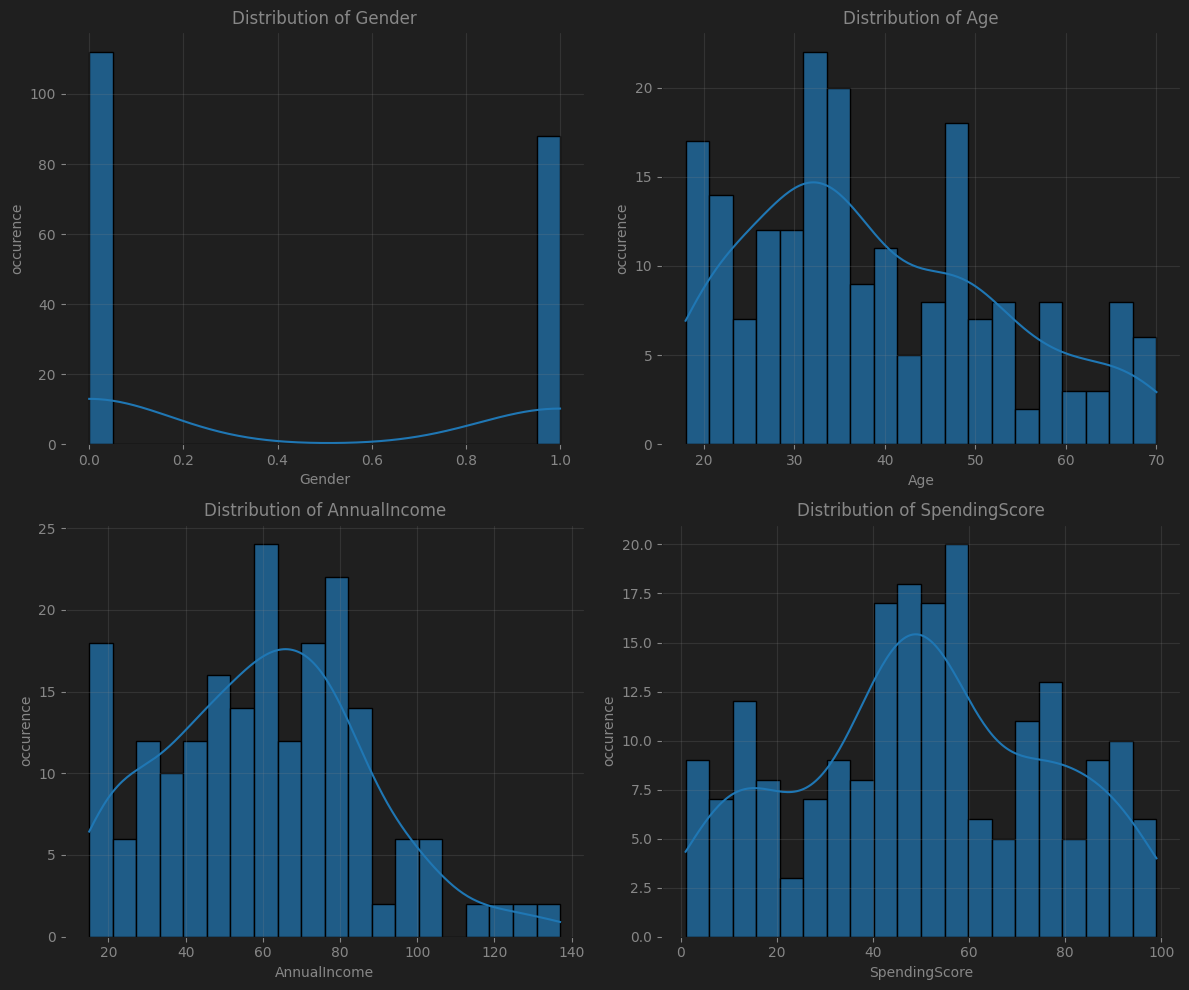

In [211]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, color=PRIMARY_COLOR, alpha=0.7, ax=ax[i], bins=20)
    ax[i].set_title(f"Distribution of {col}")
    ax[i].set_xlabel(f"{col}")
    ax[i].set_ylabel("occurence")
    ax[i].grid(True)

plt.tight_layout()
plt.show()

In [212]:
print(df['AnnualIncome'].skew())

0.3218425498619055


In [213]:
df_scaled = df.copy()

df_scaled['AnnualIncome'] = np.log10(df_scaled['AnnualIncome'])

scaler = RobustScaler()

cols_to_scale = ['Age', 'AnnualIncome', 'SpendingScore']

df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

df_scaled.head()

,Gender,Age,AnnualIncome,SpendingScore
0,1,-0.839506,-2.235221,-0.287582
1,1,-0.740741,-2.235221,0.810458
2,0,-0.790123,-2.132980,-1.150327
3,0,-0.641975,-2.132980,0.705882
4,0,-0.246914,-2.036939,-0.261438


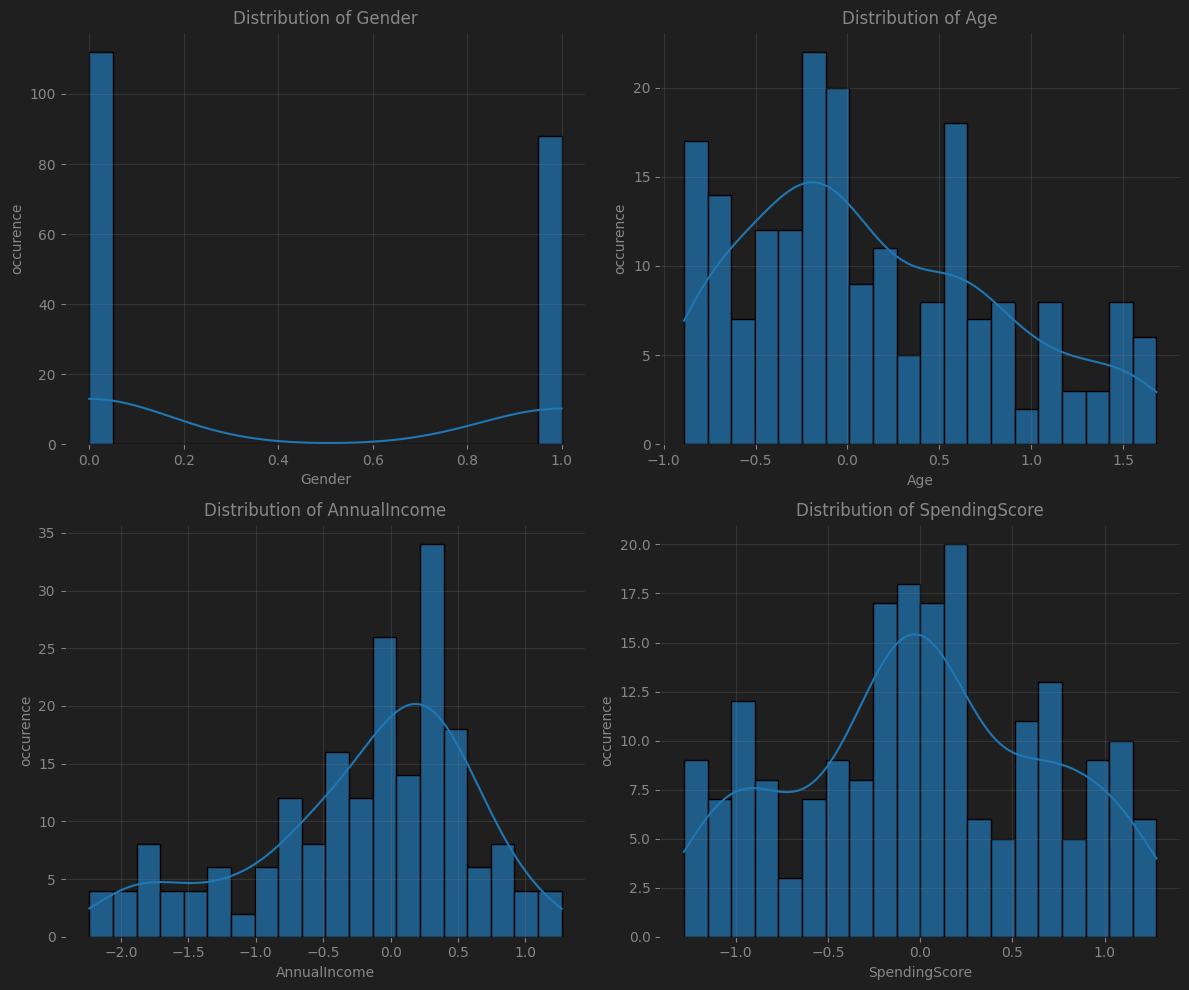

In [214]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

for i, col in enumerate(df_scaled.columns):
    sns.histplot(df_scaled[col], kde=True, color=PRIMARY_COLOR, alpha=0.7, ax=ax[i], bins=20)
    ax[i].set_title(f"Distribution of {col}")
    ax[i].set_xlabel(f"{col}")
    ax[i].set_ylabel("occurence")
    ax[i].grid(True)

plt.tight_layout()
plt.show()